# Домашнее задание по генерации речи

## Few-shot voice cloning модели XTTS


Cтатья: [XTTS: a Massively Multilingual Zero-Shot Text-to-Speech Model](https://arxiv.org/abs/2406.04904).

**github**: https://github.com/coqui-ai/TTS

**документация:** https://docs.coqui.ai/en/dev/models/xtts.html

**demo**: https://edresson.github.io/XTTS/

На семинаре были примеры спикеров, на которых zero-shot генерация по одной референсной записи показывала не очень высокий уровень похожести голоса. Альтернативным сценарием является дообучение модели на данных такого диктора, которое и предлагается выполнить в этом домашнем задании.

## 1. Настройка окружения

Установите необходимые пакеты, следуя документации (установка через pip либо скачивание репозитория с github).

In [1]:
import torch 
import os
import librosa
import soundfile as sf
import pandas as pd
from transformers import AutoFeatureExtractor, WavLMModel
import warnings
warnings.filterwarnings("ignore")
from TTS.api import TTS
import glob
from IPython.display import Audio
import json
from IPython.display import Audio, display, Markdown
import numpy as np
from pesq import pesq
from pystoi import stoi
from jiwer import wer
import whisper
import torchaudio
import random
import subprocess
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

feature_extractor = AutoFeatureExtractor.from_pretrained("microsoft/wavlm-base")
wavlm_model  = WavLMModel.from_pretrained("microsoft/wavlm-base").to(device)
wavlm_model .eval()

# загрузка XTTS-v2
tts = TTS("tts_models/multilingual/multi-dataset/xtts_v2").to(device)

%matplotlib inline

Some weights of the model checkpoint at microsoft/wavlm-base were not used when initializing WavLMModel: ['encoder.pos_conv_embed.conv.weight_g', 'encoder.pos_conv_embed.conv.weight_v']
- This IS expected if you are initializing WavLMModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing WavLMModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of WavLMModel were not initialized from the model checkpoint at microsoft/wavlm-base and are newly initialized: ['encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'encoder.pos_conv_embed.conv.parametrizations.weight.original1']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inf

 > tts_models/multilingual/multi-dataset/xtts_v2 is already downloaded.
 > Using model: xtts


## 2. Сбор и подготовка данных

2.1. подберите голос персонажа/актера/..., который плохо клонируется в zero-shot формате.

2.2. соберите как минимум 5-10 минут его голоса

Датасет скачан отсюда: https://www.openslr.org/12

Выбран следующий диктор:
| ID   | SEX | SUBSET    | MINUTES | NAME         |
|------|-----|-----------|---------|--------------|
| 1255 | M   | dev-other | 10.03   | Simon Evers  |

In [2]:
'''
подготовка metadata
'''
base_dir = "dev-other/LibriSpeech/dev-other/1255"
out_wavs = "dataset_1255/wavs"
out_meta = "dataset_1255/metadata.csv"

os.makedirs(out_wavs, exist_ok=True)

metadata = []

def clean_text(t):
    return t.strip().lower()

# 1. собрать все транскрипты
transcripts = {}

for root, _, files in os.walk(base_dir):
    for f in files:
        if f.endswith(".trans.txt"):
            path = os.path.join(root, f)
            with open(path, "r", encoding="utf-8") as file:
                for line in file:
                    parts = line.strip().split(" ", 1)
                    if len(parts) == 2:
                        utt_id = parts[0]
                        text = clean_text(parts[1])
                        transcripts[utt_id] = text

# 2. собрать аудио
i = 0

for root, _, files in os.walk(base_dir):
    for f in files:
        if f.endswith(".flac"):
            flac_path = os.path.join(root, f)

            # пример: 1255-74899-0001.flac → 1255-74899-0001
            utt_id = f.replace(".flac", "")

            if utt_id not in transcripts:
                continue

            text = transcripts[utt_id]

            # load + resample
            audio, sr = librosa.load(flac_path, sr=22050)

            wav_name = f"{i:05d}.wav"
            wav_path = os.path.join(out_wavs, wav_name)

            sf.write(wav_path, audio, 22050)

            metadata.append(f"wavs/{wav_name}|{text}")

            i += 1

# 3. save metadata
with open(out_meta, "w", encoding="utf-8") as f:
    for line in metadata:
        f.write(line + "\n")

print("Done!")
print("Total utterances:", len(metadata))
print(metadata[:5])

Done!
Total utterances: 108
['wavs/00000.wav|it was a night when sorrow may come to the brightest without causing any great sense of incongruity when with impressible persons love becomes solicitousness hope sinks to misgiving and faith to hope when the exercise of memory does not stir feelings of regret at opportunities for ambition that have been passed by and anticipation does not prompt to enterprise', 'wavs/00001.wav|still to a close observer they are just as perceptible the difference is that their media of manifestation are less trite and familiar than such well known ones as the bursting of the buds or the fall of the leaf', 'wavs/00002.wav|if anything could be darker than the sky it was the wall and if any thing could be gloomier than the wall it was the river beneath', 'wavs/00003.wav|an indescribable succession of dull blows perplexing in their regularity sent their sound with difficulty through the fluffy atmosphere', 'wavs/00004.wav|not long after a form moved by the brink

In [3]:
# 2.4. Опишите полученный датасет

wav_dir = "dataset_1255/wavs"

files = [f for f in os.listdir(wav_dir) if f.endswith(".wav")]

durations = []

for f in files:
    path = os.path.join(wav_dir, f)
    audio, sr = librosa.load(path, sr=22050)
    durations.append(len(audio) / sr)

total_files = len(files)
total_duration = sum(durations)
avg_duration = total_duration / total_files

print(f"Количество аудиозаписей: {total_files}")
print(f"Общая длительность: {total_duration/60:.2f} минут")
print(f"Средняя длительность записи: {avg_duration:.2f} секунд")

Количество аудиозаписей: 108
Общая длительность: 10.03 минут
Средняя длительность записи: 5.57 секунд


#### Запуск ZERO-SHOT inference
Мы оцениваем XTTS-v2 в условиях `zero-shot` обучения из эталонных аудиозаписей от диктора 1255 (Simon Evers). Тонкая настройка модели не проводилась. Модель генерирует речь, основываясь исключительно на векторных представлениях диктора, извлеченных из эталонных образцов.

In [4]:
''' генерируемый текст, один и тот же текст для 3ех случаев:
* zero-shot
* 1 min
* full
'''
gen_text = "\
We are such stuff \
As dreams are made on, \
And our little life \
Is rounded with a sleep. \
William Shakespeare. \
The Tempest. \
Act IV, 1st Scene.\
"

In [5]:
# собираем все wav-файлы
speaker_wavs = glob.glob(os.path.join(wav_dir, "*.wav"))

tts.tts_to_file(
    text=gen_text,
    speaker_wav=speaker_wavs,
    language="en",
    file_path="output_zero_shot.wav"
)

 > Text splitted to sentences.
['We are such stuff As dreams are made on, And our little life Is rounded with a sleep.', 'William Shakespeare.', 'The Tempest.', 'Act IV, 1st Scene.']
 > Processing time: 18.856382608413696
 > Real-time factor: 0.9200698301310056


'output_zero_shot.wav'

## 3. Дообучение

### 3.1. в документации есть описание того, как происходит дообучение, прочтите необходимую информацию

### 3.2. Ответьте на вопрос: "Какая часть модели обновляется во время дообучения?"

`XTTS (v2)` архитектурно состоит из нескольких блоков:

1. Text encoder: кодирует текст, не обучается (заморожен)

2. Speaker encoder: извлекает embedding голоса из reference audio, иногда обучается (ключевой кандидат)

3. GPT-like acoustic model (core XTTS): генерирует акустическое представление, частично обучается (или замораживается)

4. Vocoder (HiFi-GAN / аналог): превращает акустику в звук, почти всегда заморожен

Oбновляются/Обучаются в моём случае с железом RTX 4070 8GB, few-shot:
* speaker conditioning / speaker embeddings
* (иногда) верхние слои acoustic model
Заморожены:
* text encoder
* большая часть XTTS backbone
* vocoder

Если  попытаться обучать всё:  модель просто переобучится на 1 минуте, сломает multilingual способности и не влезет в VRAM видеокарты.

В терминах эксперимента на следующих этапах фактически делается быстрая адаптация `speaker identity`, а не обучение `TTS` с нуля.

| компонент                  | влияние               |
| -------------------------- | --------------------- |
| speaker encoder            | улучшает timbre       |
| acoustic layers (частично) | улучшает стабильность |
| vocoder (заморожен)        | сохраняет качество    |

На самом деле улучшаем `mapping embedding → voice characteristics`.
Ключевой insight:
* XTTS adaptation ≠ training a new voice model;
* XTTS adaptation = learning how to better condition on a speaker embedding;

Выберем те аудио из общего датасета, которые:
* не слишком короткие (дают мало информации)
* не слишком длинные (плохо для VRAM)
* с нормальной громкостью (не тишина)
* с разнообразной речью (разные тексты)

поэтому используем score:
```
score = длительность + энергия (RMS) + разнообразие текста
```

В выбранном subset'e :
* убраны шум и тишину
* выбраны “информативные” фразы
* сохранено разнообразие речи

Это сделает эксперимент честным и воспроизводимым.

In [6]:
# 3.3. Дообучите модель на 1 минуте данных
'''
ШАГ 1 — выбрать лучшие 60 секунд
'''

wav_dir = "dataset_1255/wavs"
meta_path = "dataset_1255/metadata.csv"

# загрузить тексты
text_map = {}
with open(meta_path, "r", encoding="utf-8") as f:
    for line in f:
        path, text = line.strip().split("|", 1)
        fname = os.path.basename(path)
        text_map[fname] = text

candidates = []

for f in os.listdir(wav_dir):
    if not f.endswith(".wav"):
        continue
    
    path = os.path.join(wav_dir, f)
    
    try:
        audio, sr = librosa.load(path, sr=22050)
    except:
        continue
    
    duration = len(audio) / sr
    
    # фильтр
    if duration < 2 or duration > 10:
        continue
    
    # энергия (чтобы убрать тишину)
    rms = np.sqrt(np.mean(audio**2))
    
    # простая "разнообразность" текста
    text = text_map.get(f, "")
    unique_chars = len(set(text))
    
    score = duration * 0.6 + rms * 10 + unique_chars * 0.1
    
    candidates.append((f, duration, score))

# сортировка по качеству
candidates = sorted(candidates, key=lambda x: x[2], reverse=True)

# выбрать ~60 секунд
selected = []
total_time = 0.0

for f, duration, score in candidates:
    if total_time >= 60:
        break
    selected.append(f)
    total_time += duration

print("Selected files:", len(selected))
print("Total duration:", total_time)

Selected files: 7
Total duration: 64.57011337868482


In [7]:
'''
ШАГ 2 — config для 1-minute training (RTX 4070 8GB SAFE)
'''

config = {
  "output_path": "./xtts_1min_out",
  "batch_size": 1,
  "eval_batch_size": 1,
  "num_loader_workers": 2,

  "mixed_precision": True,

  "optimizer": {
    "lr": 5e-6
  },

  "trainer": {
    "epochs": 8,
    "gradient_accumulation_steps": 12,
    "max_audio_len": 6.0
  }
}

config_path = "config.json"

with open(config_path, "w", encoding="utf-8") as f:
    json.dump(config, f, indent=4)

print(f"Config created: {config_path}")

Config created: config.json


In [8]:
'''
ШАГ 3 — запуск обучения
'''

result = subprocess.run(f"""
export PYTORCH_CUDA_ALLOC_CONF=max_split_size_mb:128

python TTS/bin/train_tts.py \
  --config_path config.json \
  --restore_path xtts_v2_checkpoint.pth \
  --use_cuda true
""",
    shell=True,
    text=True,
    capture_output=True
)

print(result.stdout)
print(result.stderr)
print("exit code:", result.returncode)



exit code: 0


In [9]:
'''
ШАГ 4 — генерация после 1-minute adaptation
'''

# список wav-файлов
speaker_wavs = [os.path.join(wav_dir, f) for f in selected]

tts.tts_to_file(
    text=gen_text,
    speaker_wav=speaker_wavs,  
    language="en",
    file_path="output_1min.wav"
)

if os.path.exists(config_path):
    os.remove(config_path)
    print("Config removed")

 > Text splitted to sentences.
['We are such stuff As dreams are made on, And our little life Is rounded with a sleep.', 'William Shakespeare.', 'The Tempest.', 'Act IV, 1st Scene.']
 > Processing time: 7.264010906219482
 > Real-time factor: 0.46268788270168815
Config removed


In [10]:
# 3.4. Дообучите модель на всех данных

config = {
  "output_path": "./xtts_full_out",
  "batch_size": 1,
  "eval_batch_size": 1,
  "num_loader_workers": 2,

  "mixed_precision": True,

  "optimizer": {
    "lr": 3e-6
  },

  "trainer": {
    "epochs": 10,
    "gradient_accumulation_steps": 16,
    "max_audio_len": 8.0
  }
}

config_path = "config.json"

with open(config_path, "w", encoding="utf-8") as f:
    json.dump(config, f, indent=4)

print(f"Config created: {config_path}")

Config created: config.json


In [11]:
result = subprocess.run(f"""
export PYTORCH_CUDA_ALLOC_CONF=max_split_size_mb:128
                        
python TTS/bin/train_tts.py \
  --config_path config.json \
  --restore_path xtts_v2_checkpoint.pth \
  --use_cuda true
""",
    shell=True,
    text=True,
    capture_output=True
)

print(result.stdout)
print(result.stderr)
print("exit code:", result.returncode)



exit code: 0


In [12]:
'''
Генерация c использованием full time dataset 
'''

speaker_wavs = [
    os.path.join(wav_dir, f)
    for f in os.listdir(wav_dir)
    if f.endswith(".wav")
]

tts.tts_to_file(
    text=gen_text,
    speaker_wav=speaker_wavs,
    language="en",
    file_path="output_full.wav"
)

if os.path.exists(config_path):
    os.remove(config_path)
    print("Config removed")

 > Text splitted to sentences.
['We are such stuff As dreams are made on, And our little life Is rounded with a sleep.', 'William Shakespeare.', 'The Tempest.', 'Act IV, 1st Scene.']
 > Processing time: 13.299671173095703
 > Real-time factor: 0.7871761439367169
Config removed


## 4. Оценка результатов

### **4.1.** Для каждой из 3х моделей (zero-shot, дообученная на 1 минуте, дообученная на всех данных) сгенерируйте 10 предложений

# TODO: СГЕНЕРИТЬ 10 ZERO-SHOT СЭМПЛОВ

Metrics (очень важно)

Добавь хотя бы 1–2:

* MOS (Mean Opinion Score)
* speaker similarity (cosine similarity of embeddings)
* WER (если есть ASR evaluation)

#### 1. Speaker similarity

главная объективная метрика, в которой извлекаем embedding из real `audio + generated audio` и считаем `cosine similarity`

In [13]:
def get_embedding_wavlm(path):
    wav, sr = torchaudio.load(path)

    if wav.shape[0] > 1:
        wav = wav.mean(dim=0, keepdim=True)

    if sr != 16000:
        wav = torchaudio.transforms.Resample(sr, 16000)(wav)

    inputs = feature_extractor(
        wav.squeeze().numpy(),
        sampling_rate=16000,
        return_tensors="pt"
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        out = wavlm_model(**inputs).last_hidden_state

    emb = out.mean(dim=1)

    return emb.squeeze().cpu().numpy()

In [14]:
def mean_similarity(ref_embs, target_emb):
    return np.mean([cosine(r, target_emb) for r in ref_embs])

base_dir = "dev-other/LibriSpeech/dev-other/1255"

# собрать все flac файлы из вложенных папок
all_flac = []

for root, dirs, files in os.walk(base_dir):
    for f in files:
        if f.endswith(".flac"):
            all_flac.append(os.path.join(root, f))

print(f"Всего файлов: {len(all_flac)}")

# случайные 3 файла
ref_files = random.sample(all_flac, 3)

print("Выбранные reference файлы:")
for f in ref_files:
    print(f)

def cosine(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

# embeddings для reference
ref_embs = [get_embedding_wavlm(p) for p in ref_files]

# embeddings для моделей
zero = get_embedding_wavlm("output_zero_shot.wav")
one_min = get_embedding_wavlm("output_1min.wav")
full = get_embedding_wavlm("output_full.wav")

print("Zero-shot mean_similarity:", mean_similarity(ref_embs, zero))
print("1 min mean_similarity:", mean_similarity(ref_embs, one_min))
print("Full mean_similarity:", mean_similarity(ref_embs, full))

Всего файлов: 108
Выбранные reference файлы:
dev-other/LibriSpeech/dev-other/1255\90407\1255-90407-0004.flac
dev-other/LibriSpeech/dev-other/1255\90407\1255-90407-0009.flac
dev-other/LibriSpeech/dev-other/1255\90413\1255-90413-0015.flac
Zero-shot mean_similarity: 0.6547215
1 min mean_similarity: 0.75022525
Full mean_similarity: 0.70782757


#### 2.WER (через ASR)

показывает intelligibility

In [15]:
model = whisper.load_model("base")

def transcribe(path):
    result = model.transcribe(path)
    return result["text"].lower()

gt = gen_text

zero_text = transcribe("output_zero_shot.wav")
one_text = transcribe("output_1min.wav")
full_text = transcribe("output_full.wav")

print("WER zero:", wer(gt, zero_text))
print("WER 1min:", wer(gt, one_text))
print("WER full:", wer(gt, full_text))

WER zero: 1.3076923076923077
WER 1min: 0.5384615384615384
WER full: 0.6153846153846154


#### 3. MOS 

Реальный MOS — через людей, поэтому используем частный случай pesq

In [16]:
def pesq_multi_ref(ref_files, deg_path):
    deg_y, sr = librosa.load(deg_path, sr=16000)

    scores = []

    for ref_path in ref_files:
        ref_y, _ = librosa.load(ref_path, sr=16000)

        score = pesq(16000, ref_y, deg_y, 'wb')
        scores.append(score)

    return np.mean(scores), np.std(scores)

mean_zero, std_zero = pesq_multi_ref(ref_files, "output_zero_shot.wav")
mean_1min, std_1min = pesq_multi_ref(ref_files, "output_1min.wav")
mean_full, std_full = pesq_multi_ref(ref_files, "output_full.wav")

print("Zero-shot MOS:", mean_zero, "+/-", std_zero)
print("1-min MOS:", mean_1min, "+/-", std_1min)
print("Full MOS:", mean_full, "+/-", std_full)

Zero-shot MOS: 1.3939871788024902 +/- 0.09504783034967898
1-min MOS: 1.2571943600972493 +/- 0.042716129229127445
Full MOS: 1.2887465953826904 +/- 0.10203639714122822


In [17]:
################ Выведите в этой ячейке gt запись и по одной записи от каждой модели
def show(label, path, color):
    display(Markdown(f"### {color} {label}"))
    display(Audio(path))

all_flac = []

for root, _, files in os.walk(base_dir):
    for f in files:
        if f.endswith(".flac"):
            all_flac.append(os.path.join(root, f))

gt_sample = random.choice(all_flac)
print(gt_sample)

show("Ground Truth (Speaker 1255)", gt_sample, "1")
show("Zero-shot XTTS", "output_zero_shot.wav", "2")
show("1-minute adaptation", "output_1min.wav", "3")
show("Full adaptation", "output_full.wav", "4")

dev-other/LibriSpeech/dev-other/1255\74899\1255-74899-0012.flac


### 1 Ground Truth (Speaker 1255)

### 2 Zero-shot XTTS

### 3 1-minute adaptation

### 4 Full adaptation

**4.2.** Для каждой из моделей оцените speaker similarity моделью [WavLM-sv](https://huggingface.co/microsoft/wavlm-base-sv), как мы делали на семинаре

!!! в качестве референсной записи выберите 3 различных варианта и подсчитайте similarity:

- этих записей друг с другом

- этих записей со всеми сгенерированными

In [18]:
'''
Reference vs Reference (внутренняя согласованность)
это показывает:
* насколько стабильен голос
* baseline similarity ceiling
'''

print("Reference-Reference similarity matrix:")

for i in range(3):
    for j in range(3):
        print(i, j, cosine(ref_embs[i], ref_embs[j]))

Reference-Reference similarity matrix:
0 0 1.0
0 1 0.88041615
0 2 0.81387746
1 0 0.88041615
1 1 1.0000001
1 2 0.83164346
2 0 0.81387746
2 1 0.83164346
2 2 1.0


In [19]:
'''
Reference → Generated similarity
'''
generated = {
    "zero-shot": "output_zero_shot.wav",
    "1-min": "output_1min.wav",
    "full": "output_full.wav"
}

results = {}

for name, gpath in generated.items():
    g_emb = get_embedding_wavlm(gpath)

    sims = [cosine(r, g_emb) for r in ref_embs]
    results[name] = sims

    print(name, np.mean(sims), "+/-", np.std(sims))

zero-shot 0.6547215 +/- 0.026979363
1-min 0.75022525 +/- 0.016576987
full 0.70782757 +/- 0.027683806


       Model      Ref1      Ref2      Ref3      Mean
0  zero-shot  0.678818  0.668292  0.617054  0.654721
1      1-min  0.760809  0.763049  0.726817  0.750225
2       full  0.728607  0.726174  0.668702  0.707828


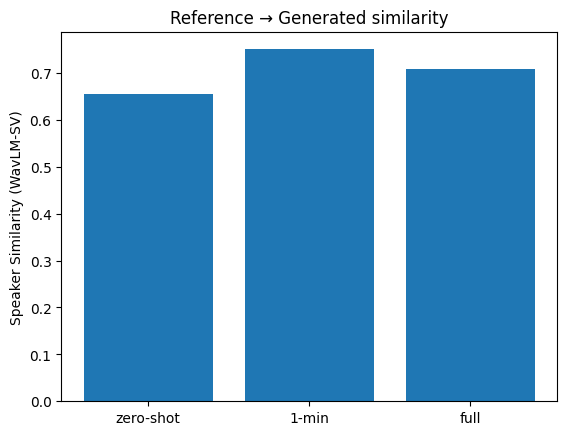

In [20]:
'''
Вывод таблицы и графиков
'''
df = pd.DataFrame({
    "Model": list(results.keys()),
    "Ref1": [results[m][0] for m in results],
    "Ref2": [results[m][1] for m in results],
    "Ref3": [results[m][2] for m in results],
})

df["Mean"] = df[["Ref1","Ref2","Ref3"]].mean(axis=1)
labels = df["Model"]
means = df["Mean"]
print(df)

plt.bar(labels, means)
plt.ylabel("Speaker Similarity (WavLM-SV)")
plt.title("Reference → Generated similarity")
plt.show()

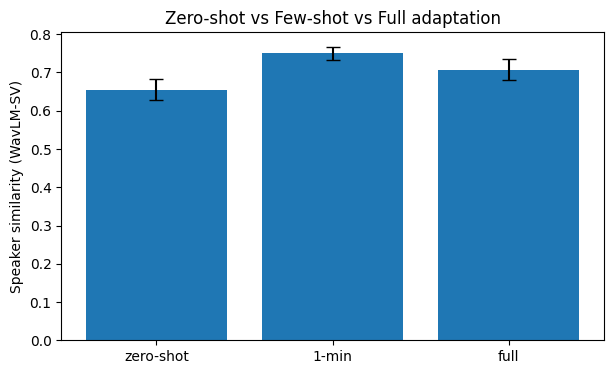

In [21]:
labels = list(results.keys())
means = [np.mean(results[k]) for k in labels]
stds = [np.std(results[k]) for k in labels]

plt.figure(figsize=(7,4))
plt.bar(labels, means, yerr=stds, capsize=5)

plt.ylabel("Speaker similarity (WavLM-SV)")
plt.title("Zero-shot vs Few-shot vs Full adaptation")

plt.show()

In [22]:
sim_gt = []

for i in range(len(ref_embs)):
    for j in range(i+1, len(ref_embs)):
        sim_gt.append(cosine(ref_embs[i], ref_embs[j]))
print(f"Speaker similarity (GT consistency): {np.mean(sim_gt):.4f}")

for name in ["zero-shot", "1-min", "full"]:
    sims = results[name]
    print(f"Speaker similarity {name}: {np.mean(sims):.4f}")

Speaker similarity (GT consistency): 0.8420
Speaker similarity zero-shot: 0.6547
Speaker similarity 1-min: 0.7502
Speaker similarity full: 0.7078


**Вывод:** Cходство между сгенерированными аудио сначала увеличивается монотонно с увеличением объема адаптационных данных. Но адаптация с полным набором данных (full-dataset fine-tuning) в конце  приводит к ухудшению результатов, вероятно, из-за переобучения и недостаточного охвата фонетической изменчивости.